# 03 — 機械学習・深層学習モデルの試行

PLSとの比較のため、MLP・1D-CNN・Random Forestを試す。

| モデル | 特性 |
|--------|------|
| PLS | 線形・低次元・解釈しやすい |
| Random Forest | 非線形・特徴量重要度あり |
| MLP | 非線形・高パラメータ |
| 1D-CNN | スペクトルの局所パターンを捉える |

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from src.utils import load_data, parse_spectra, get_groups, rmse, make_submission, setup_japanese_font
from src.preprocessing import apply_preprocessing

plt.rcParams['figure.dpi'] = 110
font_used = setup_japanese_font()
print(f'Japanese font: {font_used}')

train_df, test_df = load_data()
train_meta, y_train, X_train_raw, wn = parse_spectra(train_df)
test_meta,  _,       X_test_raw,  _  = parse_spectra(test_df)
groups = get_groups(train_meta)

PREPROCESS = 'snv+sg1'
N_SPLITS = 5

X_train = apply_preprocessing(X_train_raw, method=PREPROCESS)
X_test  = apply_preprocessing(X_test_raw,  method=PREPROCESS)
y = y_train.values

print('X_train:', X_train.shape)

Japanese font: Noto Sans JP
X_train: (1322, 1555)


## 共通CV関数

In [3]:
def cv_score(estimator, X, y, groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    scores = []
    preds_all = np.zeros(len(y))
    for tr, va in gkf.split(X, y, groups):
        est = clone(estimator)
        est.fit(X[tr], y[tr])
        p = est.predict(X[va])
        preds_all[va] = p
        scores.append(rmse(y[va], p))
    return np.mean(scores), np.std(scores), preds_all

## 1. Random Forest

In [4]:
rf = RandomForestRegressor(n_estimators=300, max_features=0.3, random_state=42, n_jobs=-1)
rf_mean, rf_std, rf_preds = cv_score(rf, X_train, y, groups)
print(f'Random Forest  CV RMSE = {rf_mean:.4f} ± {rf_std:.4f}')

Random Forest  CV RMSE = 20.1910 ± 11.3458


## 2. MLP

In [5]:
mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
    ))
])

mlp_mean, mlp_std, mlp_preds = cv_score(mlp_pipe, X_train, y, groups)
print(f'MLP            CV RMSE = {mlp_mean:.4f} ± {mlp_std:.4f}')

MLP            CV RMSE = 37.6164 ± 38.0508


## 3. 1D-CNN (PyTorch)

> PyTorchがインストールされていない場合:
> ```
> pip install torch --index-url https://download.pytorch.org/whl/cpu
> ```

In [6]:
!pip install torch


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    TORCH_AVAILABLE = True
    print('PyTorch:', torch.__version__)
except ImportError:
    TORCH_AVAILABLE = False
    print('PyTorchが未インストール。pip install torch で追加してください。')

PyTorch: 2.11.0+cpu


In [8]:
if TORCH_AVAILABLE:
    class CNN1D(nn.Module):
        def __init__(self, n_features):
            super().__init__()
            self.conv = nn.Sequential(
                nn.Conv1d(1, 32, kernel_size=15, padding=7), nn.ReLU(), nn.MaxPool1d(2),
                nn.Conv1d(32, 64, kernel_size=9, padding=4), nn.ReLU(), nn.MaxPool1d(2),
                nn.Conv1d(64, 128, kernel_size=5, padding=2), nn.ReLU(), nn.AdaptiveAvgPool1d(16),
            )
            self.fc = nn.Sequential(
                nn.Linear(128*16, 256), nn.ReLU(), nn.Dropout(0.3),
                nn.Linear(256, 64), nn.ReLU(), nn.Linear(64, 1),
            )
        def forward(self, x):
            return self.fc(self.conv(x.unsqueeze(1)).view(x.size(0), -1)).squeeze(1)

    def train_cnn_fold(X_tr, y_tr, X_va, y_va, n_epochs=100, lr=1e-3, batch_size=32):
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr).astype(np.float32)
        X_va_s = sc.transform(X_va).astype(np.float32)
        dl = DataLoader(TensorDataset(torch.from_numpy(X_tr_s),
                                      torch.from_numpy(y_tr.astype(np.float32))),
                        batch_size=batch_size, shuffle=True)
        model = CNN1D(X_tr.shape[1]).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
        criterion = nn.MSELoss()
        best_rmse, best_state, no_imp = float('inf'), None, 0
        for epoch in range(n_epochs):
            model.train()
            for xb, yb in dl:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad(); criterion(model(xb), yb).backward(); opt.step()
            sched.step()
            model.eval()
            with torch.no_grad():
                p = model(torch.from_numpy(X_va_s).to(device)).cpu().numpy()
            val_r = rmse(y_va, p)
            if val_r < best_rmse:
                best_rmse, best_state, no_imp = val_r, {k: v.clone() for k, v in model.state_dict().items()}, 0
            else:
                no_imp += 1
                if no_imp >= 20: break
        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            p = model(torch.from_numpy(X_va_s).to(device)).cpu().numpy()
        return p, best_rmse

    cnn_scores, cnn_preds = [], np.zeros(len(y))
    for fold, (tr, va) in enumerate(GroupKFold(n_splits=N_SPLITS).split(X_train, y, groups)):
        va_preds, val_rmse = train_cnn_fold(X_train[tr], y[tr], X_train[va], y[va])
        cnn_preds[va] = va_preds
        cnn_scores.append(val_rmse)
        print(f'  Fold {fold+1}: RMSE={val_rmse:.4f}')
    cnn_mean = np.mean(cnn_scores)
    print(f'\n1D-CNN  CV RMSE = {cnn_mean:.4f} ± {np.std(cnn_scores):.4f}')

  Fold 1: RMSE=8.9941
  Fold 2: RMSE=18.9399
  Fold 3: RMSE=226.1299
  Fold 4: RMSE=19.3897
  Fold 5: RMSE=11.6451

1D-CNN  CV RMSE = 57.0197 ± 84.6518


## 4. モデル比較サマリー

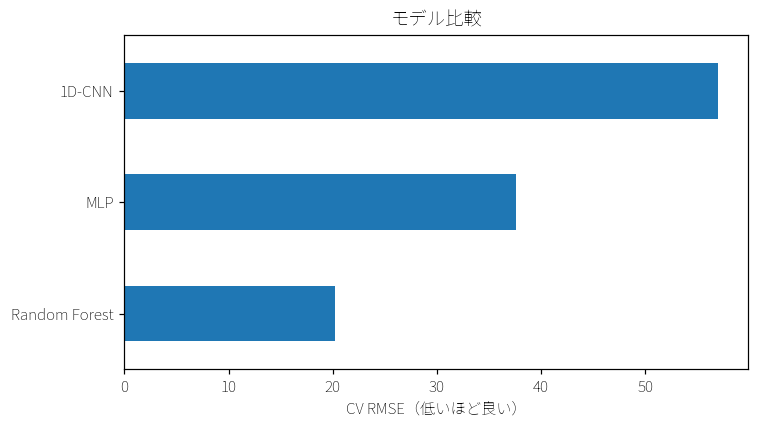

                 CV RMSE
Random Forest  20.191006
MLP            37.616383
1D-CNN         57.019745


In [11]:
# PLSのCV RMSEを02_baseline_pls.ipynbの結果から入力
PLS_CV_RMSE = None  # 例: 39.72

summary = {'Random Forest': rf_mean, 'MLP': mlp_mean}
if TORCH_AVAILABLE:
    summary['1D-CNN'] = cnn_mean
if PLS_CV_RMSE:
    summary['PLS (baseline)'] = PLS_CV_RMSE

summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=['CV RMSE']).sort_values('CV RMSE')

fig, ax = plt.subplots(figsize=(7, 4))
summary_df['CV RMSE'].plot.barh(ax=ax)
ax.set_xlabel('CV RMSE（低いほど良い）')
ax.set_title('モデル比較')
plt.tight_layout()
plt.show()
print(summary_df.to_string())

## 5. 最良モデルで提出ファイル作成

In [10]:
best_model_name = summary_df.index[0]
print(f'Best model: {best_model_name}')

if best_model_name == 'Random Forest':
    final = clone(rf)
    final.fit(X_train, y)
    test_pred = final.predict(X_test)
elif best_model_name == 'MLP':
    final = clone(mlp_pipe)
    final.fit(X_train, y)
    test_pred = final.predict(X_test)

sub = make_submission(test_meta, test_pred, path='../submissions/best_ml_model.csv')
sub.head()

Best model: Random Forest
Saved submission: ../submissions/best_ml_model.csv


,sample_number,moisture
0,95,172.002328
1,96,153.318322
2,97,142.882836
3,98,139.905016
4,99,141.061070
